**Project Implement**


**Ali Hatefi - 403133068**

In [9]:
import os
import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, datasets
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
import kagglehub
from tqdm import tqdm
import numpy as np


plt.style.use('ggplot')


In [10]:

# ==========================================
# 1. SETUP & DATASET DOWNLOAD
# ==========================================
print(" Downloading Blood Cell Dataset...")

try:
    path = kagglehub.dataset_download("sumithsingh/blood-cell-images-for-cancer-detection")
    
    def find_image_root(start_path):
        for root, dirs, files in os.walk(start_path):
            if len(dirs) > 0:
                check_sub = os.path.join(root, dirs[0])
                if os.path.isdir(check_sub) and any(f.lower().endswith(('.png', '.jpg', '.jpeg')) for f in os.listdir(check_sub)):
                    return root
        return start_path

    data_root = find_image_root(path)
    CLASSES_NAMES = sorted([d for d in os.listdir(data_root) if os.path.isdir(os.path.join(data_root, d))])
    print(f" Dataset ready at: {data_root}")
    print(f" Classes found: {CLASSES_NAMES}")

except Exception as e:
    print(f" Error downloading dataset: {e}")
    raise RuntimeError("Could not set up the dataset.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Device being used: {device}")


 Dataset ready at: <HOME>\.cache\kagglehub\datasets\sumithsingh\blood-cell-images-for-cancer-detection\versions\2
 Classes found: ['basophil', 'erythroblast', 'monocyte', 'myeloblast', 'seg_neutrophil']
 Device being used: cuda


 Number of samples per class:
  basophil       : 1000
  erythroblast   : 1000
  monocyte       : 1000
  myeloblast     : 1000
  seg_neutrophil : 1000


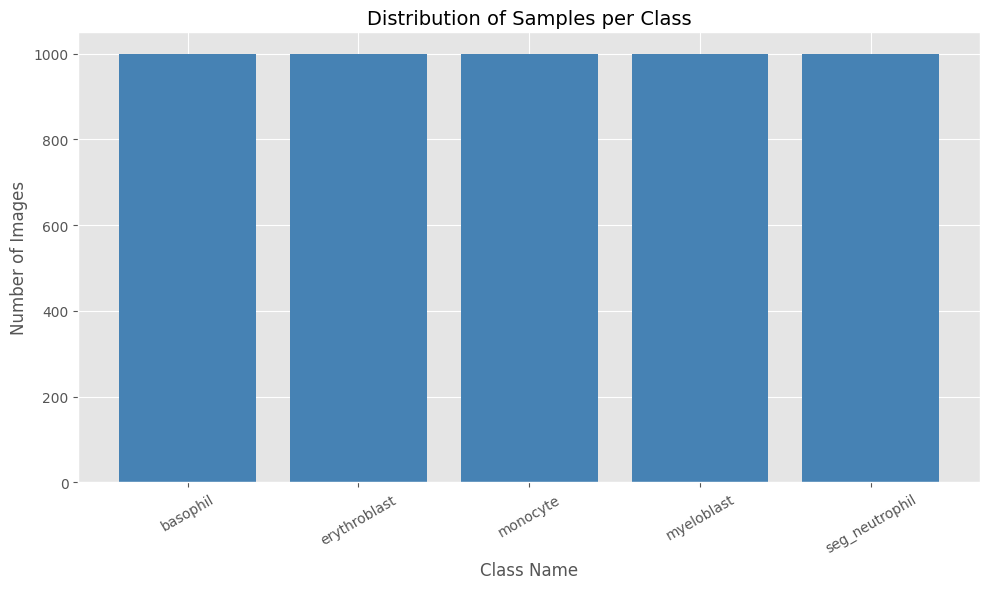

In [17]:
# Count samples per class
class_counts = {}

for cls in CLASSES_NAMES:
    cls_path = os.path.join(data_root, cls)
    images = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]
    class_counts[cls] = len(images)

# Print counts (for logging)
print(" Number of samples per class:")
for cls, cnt in class_counts.items():
    print(f"  {cls:<15}: {cnt}")

# Plot
plt.figure(figsize=(10, 6))
plt.bar(class_counts.keys(), class_counts.values(), color='steelblue')

plt.title("Distribution of Samples per Class", fontsize=14)
plt.xlabel("Class Name", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)

plt.xticks(rotation=30)
plt.tight_layout()

# Save figure for report/thesis
plt.savefig("0_class_distribution.png", dpi=300)
plt.show()

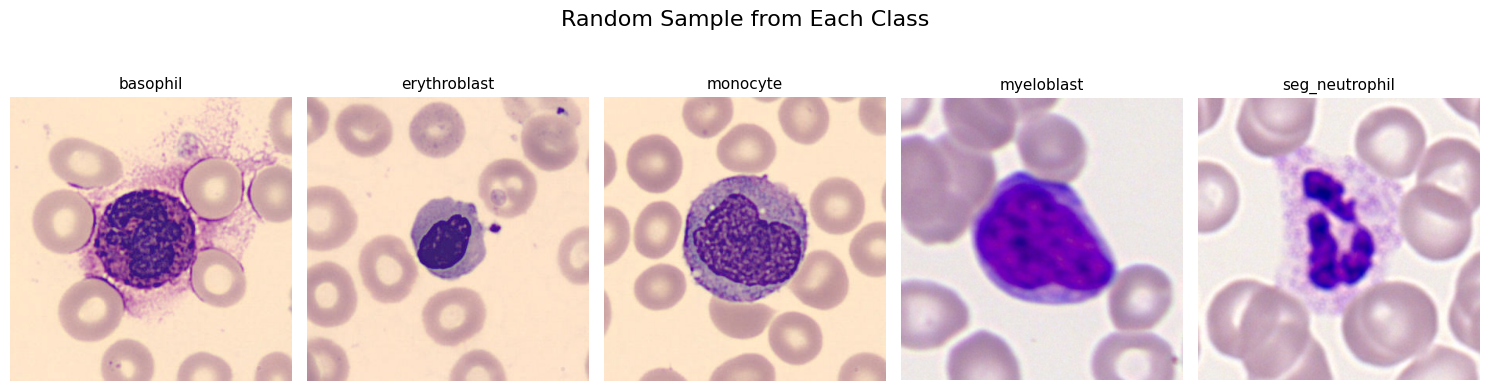

In [18]:
import random
from PIL import Image

plt.figure(figsize=(15, 4))

for idx, cls in enumerate(CLASSES_NAMES):
    cls_path = os.path.join(data_root, cls)
    
    images = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]
    
    # Randomly select one image
    img_name = random.choice(images)
    img_path = os.path.join(cls_path, img_name)
    
    img = Image.open(img_path).convert("RGB")
    
    plt.subplot(1, len(CLASSES_NAMES), idx + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(cls, fontsize=11)

plt.suptitle("Random Sample from Each Class", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.9])

# Save for report/thesis
plt.savefig("0_random_samples_per_class.png", dpi=300)
plt.show()

In [11]:

# ==========================================
# 2. UTILS: Visualization & Helpers
# ==========================================
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
        self.best_model_state = None

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_model_state = copy.deepcopy(model.state_dict())
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.best_model_state = copy.deepcopy(model.state_dict())
            self.counter = 0
    
    def restore_best_weights(self, model):
        model.load_state_dict(self.best_model_state)
        print("    Restored best model weights.")

def denormalize(tensor):
    """Reverses the ImageNet normalization for visualization."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(tensor.device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(tensor.device)
    return tensor * std + mean

In [12]:

# ==========================================
# 3. ARCHITECTURE (ConvNeXt V2)
# ==========================================
class LayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-6, data_format="channels_last"):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(normalized_shape))
        self.bias = nn.Parameter(torch.zeros(normalized_shape))
        self.eps = eps
        self.data_format = data_format
        self.normalized_shape = (normalized_shape, )
    def forward(self, x):
        if self.data_format == "channels_last":
            return F.layer_norm(x, self.normalized_shape, self.weight, self.bias, self.eps)
        elif self.data_format == "channels_first":
            u = x.mean(1, keepdim=True)
            s = (x - u).pow(2).mean(1, keepdim=True)
            x = (x - u) / torch.sqrt(s + self.eps)
            x = self.weight[:, None, None] * x + self.bias[:, None, None]
            return x

class GRN(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.gamma = nn.Parameter(torch.zeros(1, 1, 1, dim))
        self.beta = nn.Parameter(torch.zeros(1, 1, 1, dim))
    def forward(self, x):
        Gx = torch.norm(x, p=2, dim=(1,2), keepdim=True)
        Nx = Gx / (Gx.mean(dim=-1, keepdim=True) + 1e-6)
        return self.gamma * (x * Nx) + self.beta + x

class Block(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dwconv = nn.Conv2d(dim, dim, kernel_size=7, padding=3, groups=dim)
        self.norm = LayerNorm(dim, eps=1e-6)
        self.pwconv1 = nn.Linear(dim, 4 * dim)
        self.act = nn.GELU()
        self.grn = GRN(4 * dim)
        self.pwconv2 = nn.Linear(4 * dim, dim)
    def forward(self, x):
        input = x
        x = self.dwconv(x)
        x = x.permute(0, 2, 3, 1)
        x = self.norm(x)
        x = self.pwconv1(x)
        x = self.act(x)
        x = self.grn(x)
        x = self.pwconv2(x)
        x = x.permute(0, 3, 1, 2)
        x = input + x
        return x

class ConvNeXtV2_Nano(nn.Module):
    def __init__(self, in_chans=3, depths=[2, 2, 6, 2], dims=[40, 80, 160, 320]):
        super().__init__()
        self.downsample_layers = nn.ModuleList() 
        stem = nn.Sequential(nn.Conv2d(in_chans, dims[0], kernel_size=4, stride=4), LayerNorm(dims[0], eps=1e-6, data_format="channels_first"))
        self.downsample_layers.append(stem)
        for i in range(3):
            self.downsample_layers.append(nn.Sequential(LayerNorm(dims[i], eps=1e-6, data_format="channels_first"), nn.Conv2d(dims[i], dims[i+1], kernel_size=2, stride=2)))
        self.stages = nn.ModuleList() 
        for i in range(4):
            self.stages.append(nn.Sequential(*[Block(dim=dims[i]) for _ in range(depths[i])]))
        self.final_dim = dims[-1]
    def forward(self, x):
        for i in range(4):
            x = self.downsample_layers[i](x)
            x = self.stages[i](x)
        return x

class FCMAE(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(320, 160, kernel_size=2, stride=2), Block(160),
            nn.ConvTranspose2d(160, 80, kernel_size=2, stride=2), Block(80),
            nn.ConvTranspose2d(80, 40, kernel_size=2, stride=2), Block(40),
            nn.ConvTranspose2d(40, 3, kernel_size=4, stride=4),
        )
    def forward(self, x, mask_ratio=0.6):
        N, C, H, W = x.shape
        mask = torch.rand(N, 1, H, W, device=x.device)
        mask = torch.where(mask > mask_ratio, 1.0, 0.0) 
        x_masked = x * mask
        latent = self.encoder(x_masked)
        reconstruction = self.decoder(latent)
        return reconstruction, x, mask

class FineTuneModel(nn.Module):
    def __init__(self, encoder, num_classes, dropout_rate=0.5):
        super().__init__()
        self.encoder = encoder
        self.norm = LayerNorm(encoder.final_dim, eps=1e-6, data_format="channels_first")
        self.dropout = nn.Dropout(p=dropout_rate)
        self.head = nn.Linear(encoder.final_dim, num_classes)
    def forward(self, x):
        x = self.encoder(x)
        x = self.norm(x)
        x = x.mean([-2, -1]) 
        x = self.dropout(x)
        x = self.head(x)
        return x


In [13]:

# ==========================================
# 4. EXECUTION & VISUALIZATION
# ==========================================

img_size = 128
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
full_dataset = datasets.ImageFolder(root=data_root, transform=transform)
num_classes = len(CLASSES_NAMES)

# Split
total_size = len(full_dataset)
ssl_size = int(0.50 * total_size)
ft_train_size = int(0.25 * total_size)
ft_val_size = int(0.10 * total_size)
test_size = total_size - ssl_size - ft_train_size - ft_val_size

ds_ssl, ds_ft_train, ds_ft_val, ds_test = random_split(
    full_dataset, [ssl_size, ft_train_size, ft_val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

dl_ssl = DataLoader(ds_ssl, batch_size=64, shuffle=True, num_workers=2)
dl_ft_train = DataLoader(ds_ft_train, batch_size=64, shuffle=True, num_workers=2)
dl_ft_val = DataLoader(ds_ft_val, batch_size=64, shuffle=False, num_workers=2)
dl_test = DataLoader(ds_test, batch_size=64, shuffle=False, num_workers=2)

print(f" Dataset: SSL={len(ds_ssl)}, Train={len(ds_ft_train)}, Val={len(ds_ft_val)}, Test={len(ds_test)}")

 Dataset: SSL=2500, Train=1250, Val=500, Test=750



🔹 Phase 1: SSL Pre-training...


SSL Epoch 15: 100%|██████████| 40/40 [00:09<00:00,  4.42it/s, loss=0.0540]


 Generating SSL Reconstruction Image...


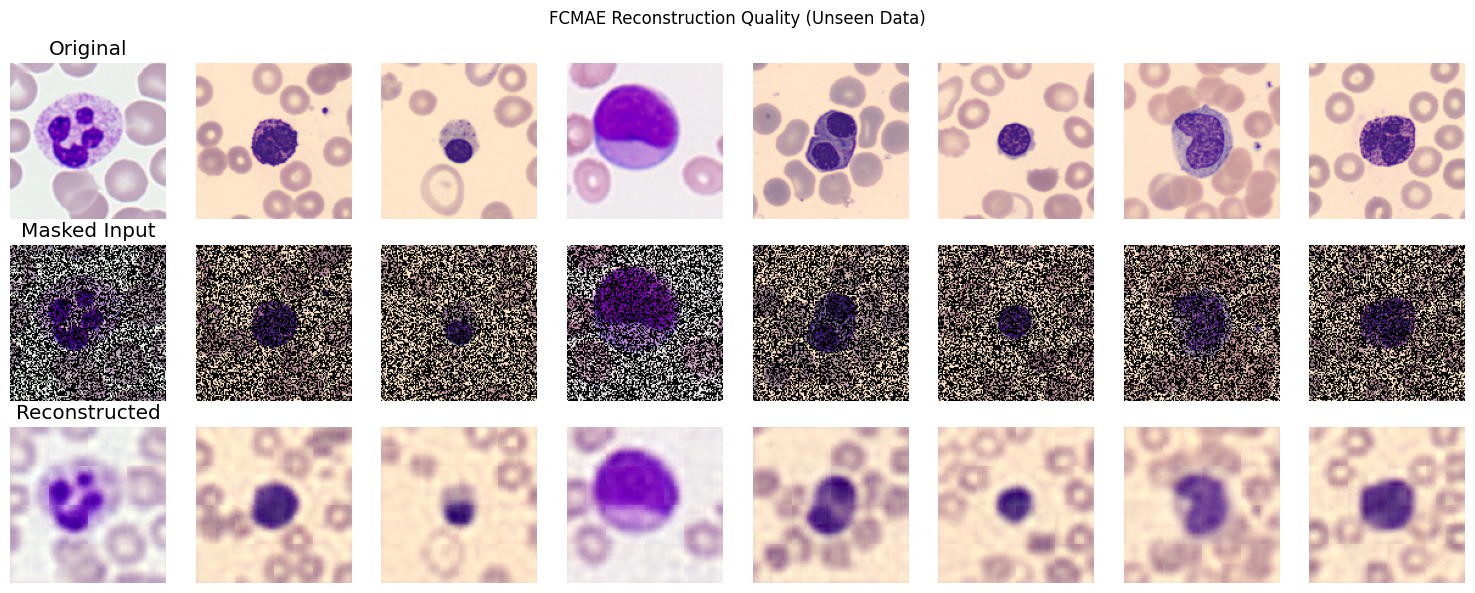

In [14]:
# --- PHASE 1: SSL ---
print("\n🔹 Phase 1: SSL Pre-training...")
base_encoder = ConvNeXtV2_Nano(in_chans=3)
ssl_model = FCMAE(encoder=base_encoder).to(device)
optimizer_ssl = optim.AdamW(ssl_model.parameters(), lr=1e-3, weight_decay=0.05)
criterion_ssl = nn.MSELoss()

ssl_losses = []

ssl_model.train()
for epoch in range(15): # Epochs
    epoch_loss = 0
    pbar = tqdm(dl_ssl, desc=f"SSL Epoch {epoch+1}")
    for imgs, _ in pbar:
        imgs = imgs.to(device)
        recon, original, mask = ssl_model(imgs, mask_ratio=0.6)
        loss = criterion_ssl(recon, original)
        
        optimizer_ssl.zero_grad()
        loss.backward()
        optimizer_ssl.step()
        epoch_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")
    ssl_losses.append(epoch_loss / len(dl_ssl))

# --- VISUALIZATION 1: SSL RECONSTRUCTION ---
print(" Generating SSL Reconstruction Image...")
ssl_model.eval()
with torch.no_grad():
    test_imgs, _ = next(iter(dl_test))
    test_imgs = test_imgs[:8].to(device) # Take 8 images
    recon, original, mask = ssl_model(test_imgs, mask_ratio=0.6)
    
    # Denormalize for plotting
    original = denormalize(original).cpu()
    recon = denormalize(recon).cpu()
    masked_img = original * mask.cpu()

    fig, axs = plt.subplots(3, 8, figsize=(15, 6))
    for i in range(8):
        axs[0, i].imshow(original[i].permute(1, 2, 0).clamp(0, 1))
        axs[0, i].axis('off')
        if i==0: axs[0, i].set_title("Original")
        
        axs[1, i].imshow(masked_img[i].permute(1, 2, 0).clamp(0, 1))
        axs[1, i].axis('off')
        if i==0: axs[1, i].set_title("Masked Input")
        
        axs[2, i].imshow(recon[i].permute(1, 2, 0).clamp(0, 1))
        axs[2, i].axis('off')
        if i==0: axs[2, i].set_title("Reconstructed")
    
    plt.suptitle("FCMAE Reconstruction Quality (Unseen Data)")
    plt.tight_layout()
    plt.savefig("1_ssl_reconstruction.png", dpi=300)
    plt.show()


In [15]:

# --- PHASE 2: FINE-TUNING ---
print("\n🔹 Phase 2: Fine-Tuning...")
classifier_model = FineTuneModel(ssl_model.encoder, num_classes=num_classes, dropout_rate=0.5).to(device)
optimizer_ft = optim.AdamW(classifier_model.parameters(), lr=5e-4, weight_decay=1e-4)
criterion_ft = nn.CrossEntropyLoss()
early_stopper = EarlyStopping(patience=5, min_delta=0.001)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

EPOCHS = 50
for epoch in range(EPOCHS):
    # Train
    classifier_model.train()
    t_loss, t_corr, t_tot = 0, 0, 0
    for imgs, labels in tqdm(dl_ft_train, desc=f"FT Epoch {epoch+1}"):
        imgs, labels = imgs.to(device), labels.to(device)
        out = classifier_model(imgs)
        loss = criterion_ft(out, labels)
        
        optimizer_ft.zero_grad()
        loss.backward()
        optimizer_ft.step()
        
        t_loss += loss.item()
        _, pred = torch.max(out, 1)
        t_corr += (pred == labels).sum().item()
        t_tot += labels.size(0)
        
    # Val
    classifier_model.eval()
    v_loss, v_corr, v_tot = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in dl_ft_val:
            imgs, labels = imgs.to(device), labels.to(device)
            out = classifier_model(imgs)
            loss = criterion_ft(out, labels)
            v_loss += loss.item()
            _, pred = torch.max(out, 1)
            v_corr += (pred == labels).sum().item()
            v_tot += labels.size(0)
    
    # Stats
    history['train_loss'].append(t_loss/len(dl_ft_train))
    history['val_loss'].append(v_loss/len(dl_ft_val))
    history['train_acc'].append(100*t_corr/t_tot)
    history['val_acc'].append(100*v_corr/v_tot)
    
    print(f"   Val Loss: {history['val_loss'][-1]:.4f} | Val Acc: {history['val_acc'][-1]:.2f}%")
    print(f"   train Loss: {history['train_loss'][-1]:.4f} | Train Acc: {history['train_acc'][-1]:.2f}%")

    early_stopper(history['val_loss'][-1], classifier_model)
    if early_stopper.early_stop:
        print(" Early Stopping!")
        break
        
early_stopper.restore_best_weights(classifier_model)


🔹 Phase 2: Fine-Tuning...


FT Epoch 1: 100%|██████████| 20/20 [00:06<00:00,  3.05it/s]


   Val Loss: 0.7280 | Val Acc: 71.40%
   train Loss: 0.9794 | Train Acc: 56.88%


FT Epoch 2: 100%|██████████| 20/20 [00:06<00:00,  2.93it/s]


   Val Loss: 0.5180 | Val Acc: 83.40%
   train Loss: 0.5037 | Train Acc: 81.12%


...

   Val Loss: 0.2940 | Val Acc: 93.20%
   train Loss: 0.0075 | Train Acc: 99.92%


FT Epoch 15: 100%|██████████| 20/20 [00:06<00:00,  3.00it/s]


   Val Loss: 0.3023 | Val Acc: 92.00%
   train Loss: 0.0036 | Train Acc: 100.00%


FT Epoch 16: 100%|██████████| 20/20 [00:06<00:00,  3.09it/s]


   Val Loss: 0.4175 | Val Acc: 92.20%
   train Loss: 0.0041 | Train Acc: 100.00%
 Early Stopping!
    Restored best model weights.


 Generating Training Curves...


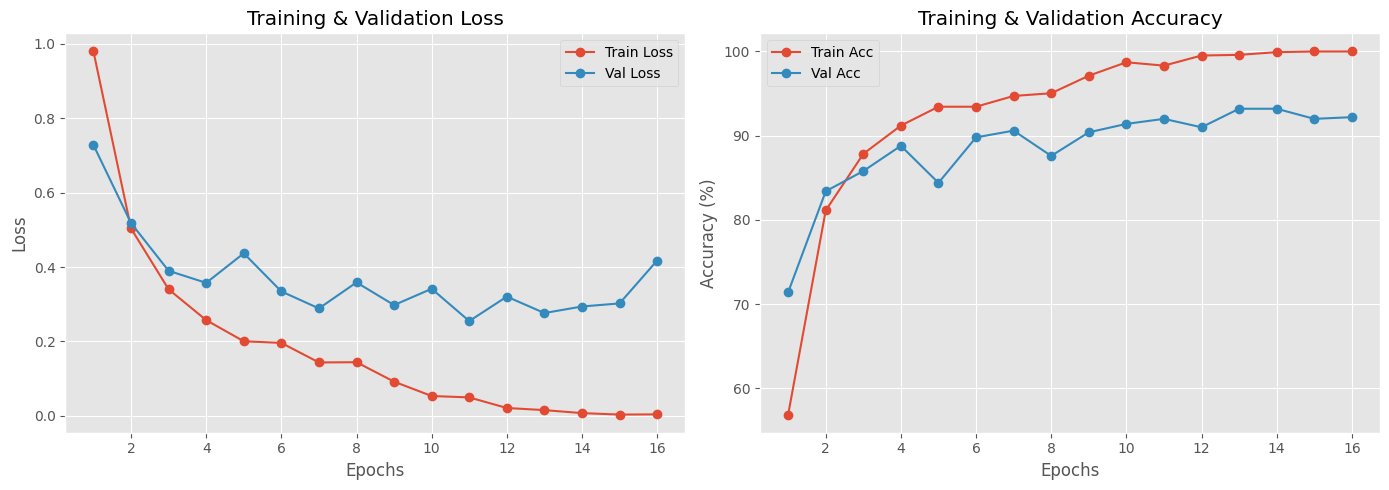


🔹 Phase 3: Final Evaluation...


Testing: 100%|██████████| 12/12 [00:05<00:00,  2.16it/s]



 Classification Report:
                precision    recall  f1-score   support

      basophil     0.8750    0.9545    0.9130       132
  erythroblast     0.9740    0.9434    0.9585       159
      monocyte     0.9342    0.8931    0.9132       159
    myeloblast     0.9595    1.0000    0.9793       142
seg_neutrophil     0.9934    0.9557    0.9742       158

      accuracy                         0.9480       750
     macro avg     0.9472    0.9493    0.9476       750
  weighted avg     0.9495    0.9480    0.9481       750

 Generating Confusion Matrix...


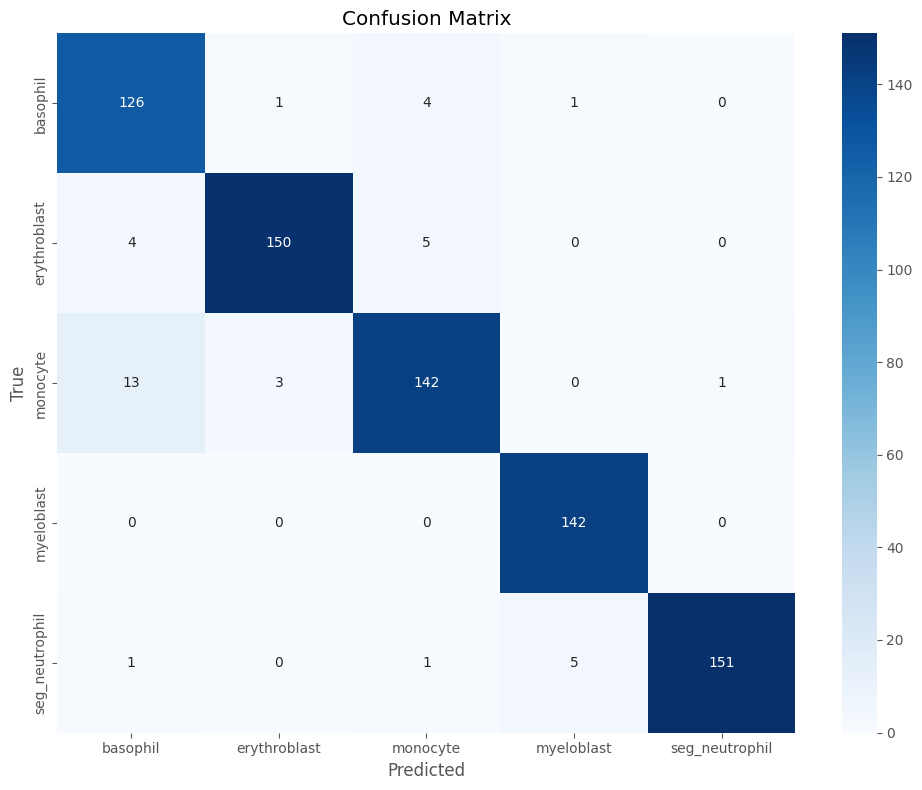

 Generating ROC Curves...


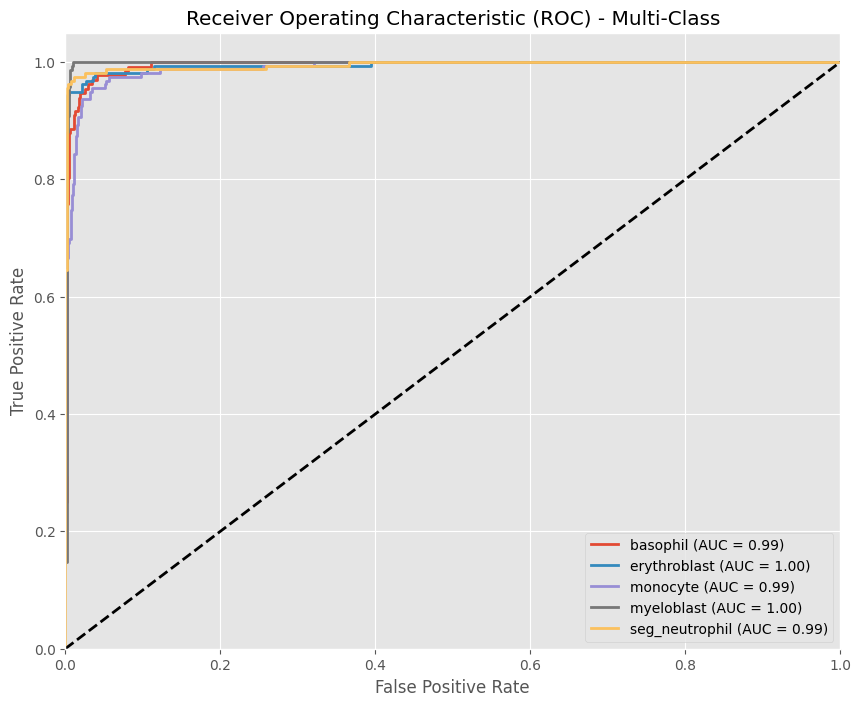


 FINAL TEST ACCURACY: 94.80%


In [16]:


# --- VISUALIZATION 2: TRAINING CURVES ---
print(" Generating Training Curves...")
epochs_range = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(14, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_loss'], label='Train Loss', marker='o')
plt.plot(epochs_range, history['val_loss'], label='Val Loss', marker='o')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_acc'], label='Train Acc', marker='o')
plt.plot(epochs_range, history['val_acc'], label='Val Acc', marker='o')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("2_training_curves.png", dpi=300)
plt.show()

# --- PHASE 3: EVALUATION & METRICS ---
print("\n🔹 Phase 3: Final Evaluation...")
classifier_model.eval()
y_true = []
y_pred = []
y_score = [] # For ROC

with torch.no_grad():
    for imgs, labels in tqdm(dl_test, desc="Testing"):
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = classifier_model(imgs)
        probs = F.softmax(outputs, dim=1)
        
        _, predicted = torch.max(outputs, 1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())
        y_score.extend(probs.cpu().numpy())

# 1. Classification Report
print("\n Classification Report:")
report = classification_report(y_true, y_pred, target_names=CLASSES_NAMES, digits=4)
print(report)
with open("classification_report.txt", "w") as f:
    f.write(report)

# 2. Confusion Matrix Heatmap
print(" Generating Confusion Matrix...")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES_NAMES, yticklabels=CLASSES_NAMES)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig("3_confusion_matrix.png", dpi=300)
plt.show()

# 3. ROC Curve (Multiclass)
print(" Generating ROC Curves...")
y_true_bin = label_binarize(y_true, classes=range(num_classes))
y_score = np.array(y_score)

plt.figure(figsize=(10, 8))

# Compute ROC curve and ROC area for each class
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{CLASSES_NAMES[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Multi-Class')
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig("4_roc_curves.png", dpi=300)
plt.show()

final_acc = 100 * np.sum(np.array(y_pred) == np.array(y_true)) / len(y_true)
print(f"\n FINAL TEST ACCURACY: {final_acc:.2f}%")

